# 00. 탐색적 데이터 분석 (EDA)
서울시 공공자전거 따릉이 2025년 10~12월 대여 데이터 탐색

In [1]:
import sys, gc
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트
for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

from src.data_loader import load_raw, parse_datetimes, clean, add_time_features, build_station_hourly, save_processed
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
# 전체 데이터 로드 (개발 중에는 sample_n=100_000 사용 가능)
df_raw = load_raw()
print(f"\n📊 데이터 크기: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열")
df_raw.head(3)

📂 Loading: /Users/hayoung/seoul-bike-ml/data/raw/seoul_bike_rentals_2025_10.csv


   ↳ shape: (3407801, 17)
📂 Loading: /Users/hayoung/seoul-bike-ml/data/raw/seoul_bike_rentals_2025_11.csv


   ↳ shape: (3186968, 17)
📂 Loading: /Users/hayoung/seoul-bike-ml/data/raw/seoul_bike_rentals_2025_12.csv


   ↳ shape: (1965170, 17)
   ↳ 합산 shape: (8559939, 17)

📊 데이터 크기: 8,559,939행 × 17열


,bike_id,rent_dt,rent_stn_no,rent_stn_name,rent_dock,rtrn_dt,rtrn_stn_no,rtrn_stn_name,rtrn_dock,use_min,use_m,birth_year,gender,user_type,rent_stn_id,rtrn_stn_id,bike_type
0,SPB-66821,2025-10-01 00:00:15,03792,화곡본동시장 입구,0,2025-10-01 00:02:06,01148,볏골공원,0.00,1,330.00,NaN,NaN,NaN,ST-2551,ST-538,일반자전거
1,SPB-82882,2025-10-01 00:01:28,04483,잠실나들목4,99,2025-10-01 00:02:34,02645,잠실나들목2(엘스아파트136동),99.00,1,111.30,NaN,NaN,NaN,ST-2593,ST-1797,새싹자전거
2,SPB-71658,2025-10-01 00:01:30,00716,신정6동 주민센터 인근,0,2025-10-01 00:02:48,00794,양천문화회관,0.00,1,0.00,1980.00,M,내국인,ST-428,ST-2395,일반자전거


In [3]:
# 컬럼별 결측치 현황
null_df = pd.DataFrame({
    "컬럼": df_raw.columns,
    "결측수": df_raw.isnull().sum().values,
    "결측율(%)": (df_raw.isnull().mean() * 100).round(1).values,
    "dtype": df_raw.dtypes.values
})
print(null_df.to_string(index=False))

           컬럼     결측수  결측율(%)   dtype
      bike_id       0    0.00     str
      rent_dt       0    0.00     str
  rent_stn_no       0    0.00     str
rent_stn_name       0    0.00     str
    rent_dock       0    0.00   int64
      rtrn_dt       0    0.00     str
  rtrn_stn_no   45962    0.50     str
rtrn_stn_name   45962    0.50     str
    rtrn_dock   52810    0.60 float64
      use_min       0    0.00   int64
        use_m       0    0.00 float64
   birth_year 1920736   22.40 float64
       gender 3493313   40.80     str
    user_type 1448256   16.90     str
  rent_stn_id       0    0.00     str
  rtrn_stn_id   45962    0.50     str
    bike_type       0    0.00     str


In [4]:
df = parse_datetimes(df_raw)
df = clean(df)
df = add_time_features(df)
del df_raw; gc.collect()
print(f"\n정제 후 행 수: {len(df):,}")
df.dtypes

✅ clean() 완료 → shape: (8559939, 20)



정제 후 행 수: 8,559,939


bike_id                       str
rent_dt            datetime64[us]
rent_stn_no                   str
rent_stn_name                 str
rent_dock                   int64
rtrn_dt            datetime64[us]
rtrn_stn_no                   str
rtrn_stn_name                 str
rtrn_dock                 float64
use_min                     int64
use_m                     float64
birth_year                float64
gender                        str
user_type                     str
rent_stn_id                   str
rtrn_stn_id                   str
bike_type                     str
use_min_calc              float64
use_min_outlier              bool
use_m_outlier                bool
hour                        int32
dow                         int32
day                         int32
week                        int64
is_weekend                  int64
time_slot                     str
dtype: object

## 2. 시간별 대여 패턴

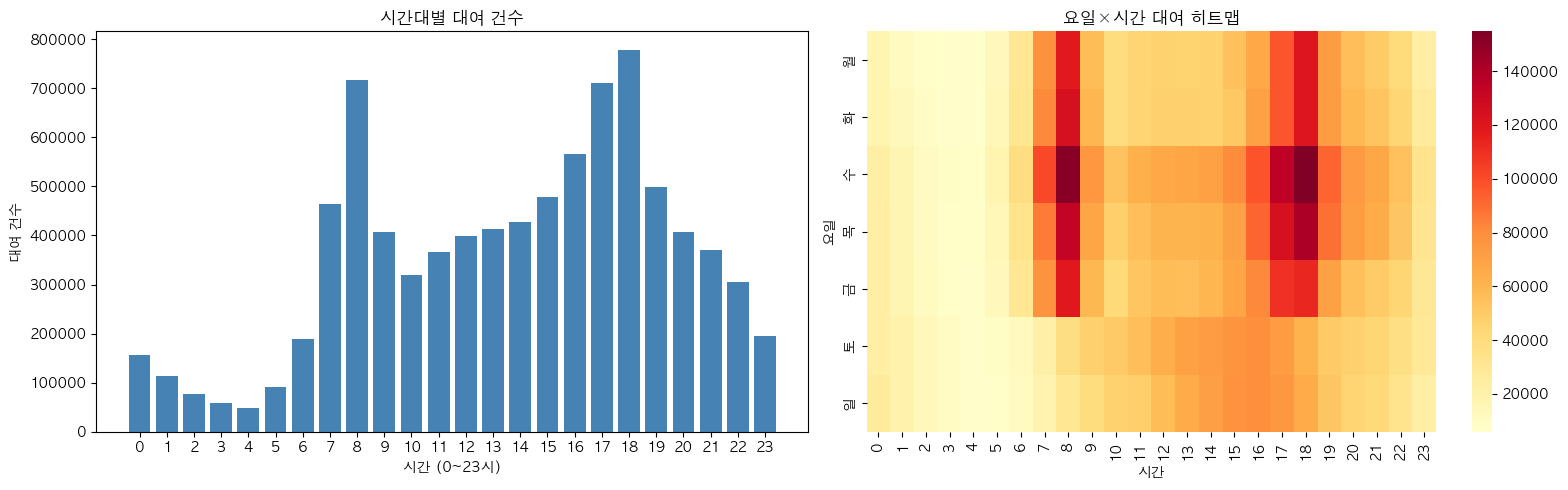

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 시간대별 대여 건수
hourly_cnt = df.groupby("hour").size().reset_index(name="count")
axes[0].bar(hourly_cnt["hour"], hourly_cnt["count"], color="steelblue")
axes[0].set_title("시간대별 대여 건수")
axes[0].set_xlabel("시간 (0~23시)")
axes[0].set_ylabel("대여 건수")
axes[0].set_xticks(range(24))

# 요일×시간 히트맵
pivot = df.groupby(["dow", "hour"]).size().unstack(fill_value=0)
pivot.index = ["월", "화", "수", "목", "금", "토", "일"]
sns.heatmap(pivot, ax=axes[1], cmap="YlOrRd", fmt="d", annot=False)
axes[1].set_title("요일×시간 대여 히트맵")
axes[1].set_xlabel("시간")
axes[1].set_ylabel("요일")

plt.tight_layout()
plt.savefig("../reports/figures/hourly_heatmap.png", dpi=150)
plt.show()

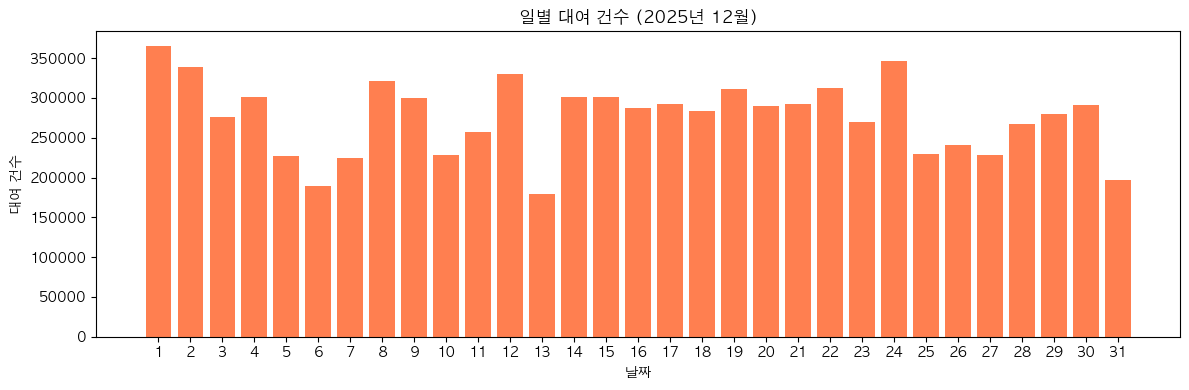

In [6]:
daily = df.groupby("day").size().reset_index(name="count")
plt.figure(figsize=(12, 4))
plt.bar(daily["day"], daily["count"], color="coral")
plt.title("일별 대여 건수 (2025년 12월)")
plt.xlabel("날짜")
plt.ylabel("대여 건수")
plt.xticks(daily["day"])
plt.tight_layout()
plt.savefig("../reports/figures/daily_pattern.png", dpi=150)
plt.show()

## 3. 대여소 분석

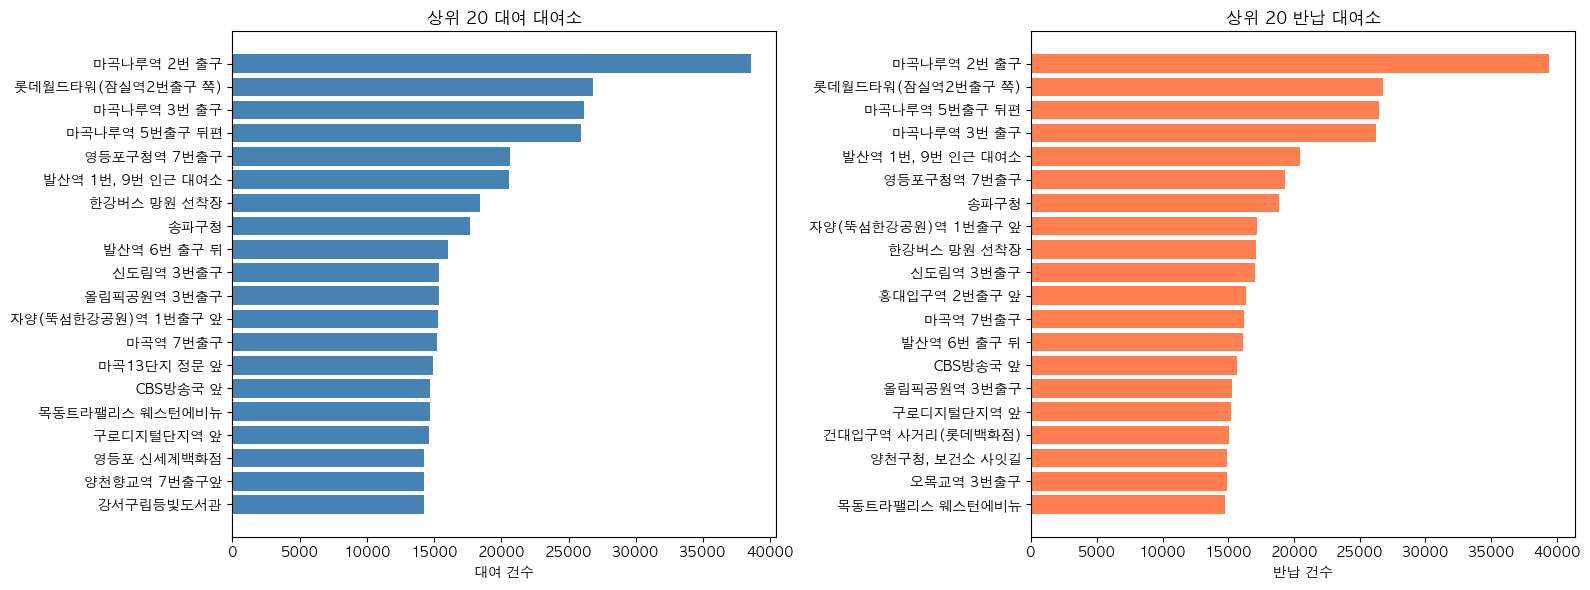

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상위 대여소 (대여)
top_rent = df["rent_stn_name"].value_counts().head(20)
axes[0].barh(top_rent.index[::-1], top_rent.values[::-1], color="steelblue")
axes[0].set_title("상위 20 대여 대여소")
axes[0].set_xlabel("대여 건수")

# 상위 대여소 (반납)
top_rtrn = df["rtrn_stn_name"].value_counts().head(20)
axes[1].barh(top_rtrn.index[::-1], top_rtrn.values[::-1], color="coral")
axes[1].set_title("상위 20 반납 대여소")
axes[1].set_xlabel("반납 건수")

plt.tight_layout()
plt.savefig("../reports/figures/top_stations.png", dpi=150)
plt.show()

In [8]:
rent_cnt = df.groupby("rent_stn_id").size().rename("rent")
rtrn_cnt = df.dropna(subset=["rtrn_stn_id"]).groupby("rtrn_stn_id").size().rename("rtrn")
flow = pd.concat([rent_cnt, rtrn_cnt], axis=1).fillna(0)
flow["net_flow"] = flow["rent"] - flow["rtrn"]
print("순 유출 상위 10개 대여소 (자전거 부족 위험):")
print(flow.nlargest(10, "net_flow"))
print("\n순 유입 상위 10개 대여소 (자전거 과잉 위험):")
print(flow.nsmallest(10, "net_flow"))

순 유출 상위 10개 대여소 (자전거 부족 위험):
           rent  rtrn  net_flow
ST-318  3131.00   734   2397.00
ST-1197 5612.00  3234   2378.00
ST-674  3791.00  1557   2234.00
ST-385  5446.00  3325   2121.00
ST-391  4204.00  2159   2045.00
ST-1854 3425.00  1393   2032.00
ST-2081 6391.00  4374   2017.00
ST-2901 2302.00   344   1958.00
ST-445  8284.00  6570   1714.00
ST-2156 5555.00  3856   1699.00

순 유입 상위 10개 대여소 (자전거 과잉 위험):
            rent   rtrn  net_flow
ST-2264  8092.00  11699  -3607.00
ST-18   13009.00  16319  -3310.00
ST-3368  6593.00   8815  -2222.00
ST-3044  5555.00   7654  -2099.00
ST-1990  9464.00  11493  -2029.00
ST-99   15297.00  17200  -1903.00
ST-3142 12877.00  14725  -1848.00
ST-3372  3588.00   5380  -1792.00
ST-3094 12789.00  14569  -1780.00
ST-699   4785.00   6449  -1664.00


## 4. 이용 시간 및 거리 분포

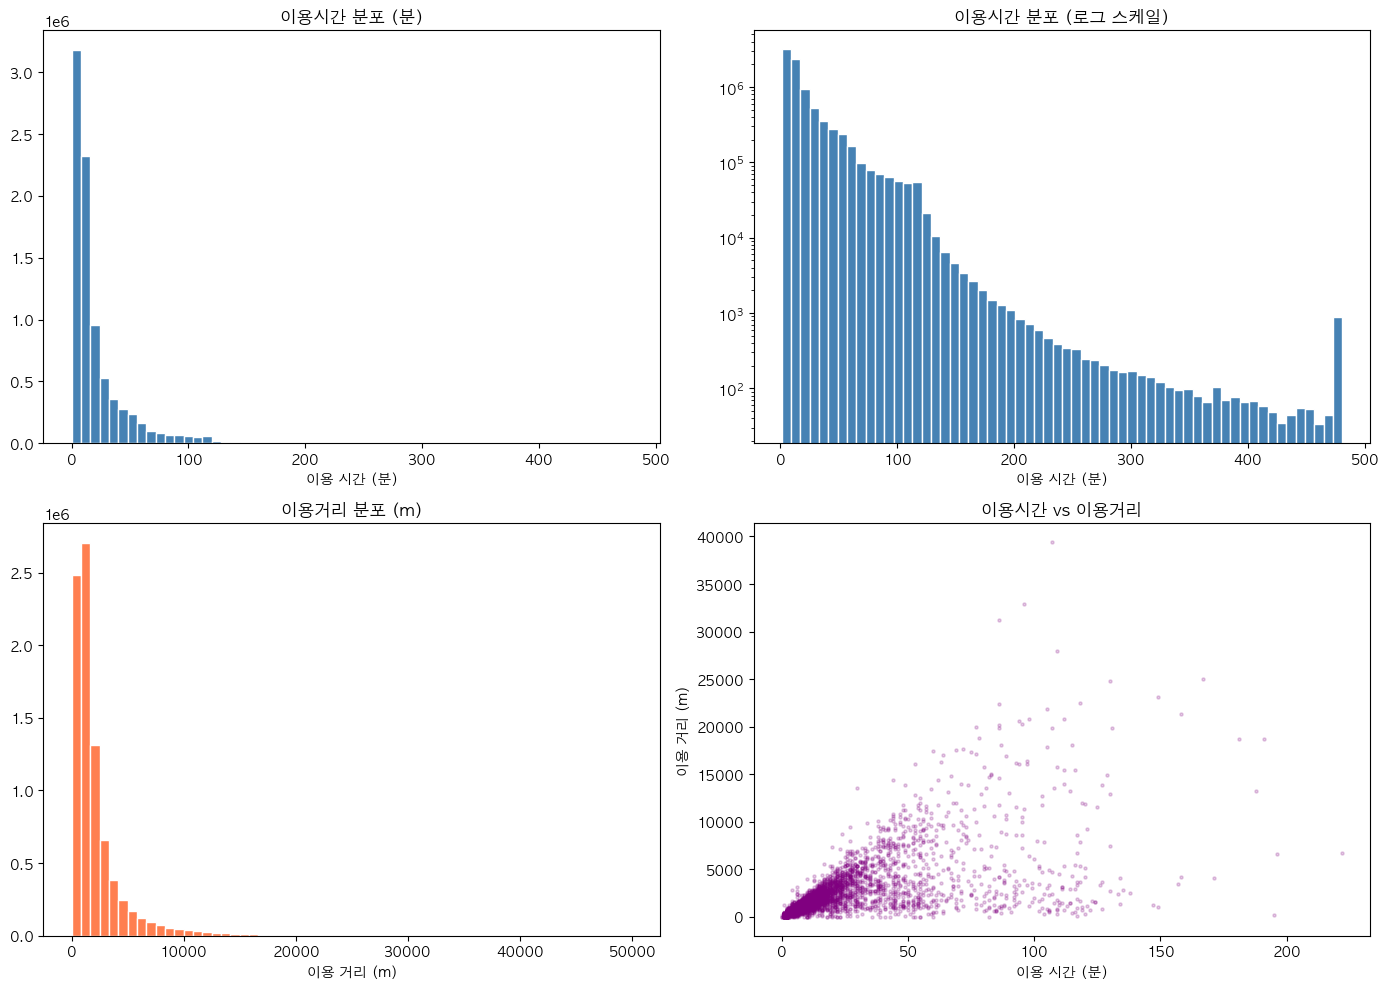

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 이용시간 히스토그램
axes[0,0].hist(df["use_min"].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[0,0].set_title("이용시간 분포 (분)")
axes[0,0].set_xlabel("이용 시간 (분)")

# 이용시간 로그스케일
axes[0,1].hist(df["use_min"].dropna() + 1, bins=60, color="steelblue", edgecolor="white", log=True)
axes[0,1].set_title("이용시간 분포 (로그 스케일)")
axes[0,1].set_xlabel("이용 시간 (분)")

# 이용거리 히스토그램
axes[1,0].hist(df["use_m"].dropna(), bins=60, color="coral", edgecolor="white")
axes[1,0].set_title("이용거리 분포 (m)")
axes[1,0].set_xlabel("이용 거리 (m)")

# 시간 vs 거리 산점도
sample = df[["use_min", "use_m"]].dropna().sample(min(5000, len(df)), random_state=42)
axes[1,1].scatter(sample["use_min"], sample["use_m"], alpha=0.2, s=5, color="purple")
axes[1,1].set_title("이용시간 vs 이용거리")
axes[1,1].set_xlabel("이용 시간 (분)")
axes[1,1].set_ylabel("이용 거리 (m)")

plt.tight_layout()
plt.savefig("../reports/figures/usage_distribution.png", dpi=150)
plt.show()

## 5. 사용자 인구통계

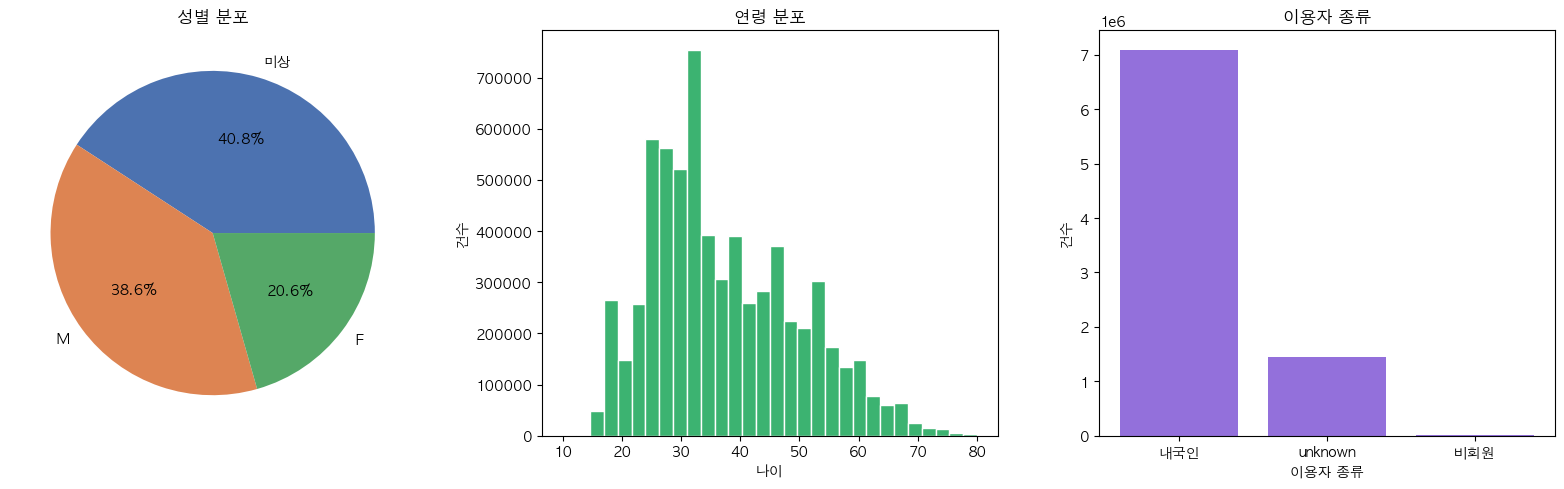

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 성별 분포
gender_cnt = df["gender"].value_counts(dropna=False)
gender_cnt.index = gender_cnt.index.fillna("미상")
axes[0].pie(gender_cnt.values, labels=gender_cnt.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("성별 분포")

# 연령대 분포
df["age"] = 2025 - df["birth_year"]
age_valid = df["age"].dropna()
age_valid = age_valid[(age_valid >= 10) & (age_valid <= 80)]
axes[1].hist(age_valid, bins=30, color="mediumseagreen", edgecolor="white")
axes[1].set_title("연령 분포")
axes[1].set_xlabel("나이")
axes[1].set_ylabel("건수")

# 이용자종류
utype = df["user_type"].value_counts()
axes[2].bar(utype.index, utype.values, color="mediumpurple")
axes[2].set_title("이용자 종류")
axes[2].set_xlabel("이용자 종류")
axes[2].set_ylabel("건수")

plt.tight_layout()
plt.savefig("../reports/figures/demographics.png", dpi=150)
plt.show()

## 6. 자전거 종류 분석

                건수  평균이용시간  평균이용거리
bike_type                         
새싹자전거       130397   19.90 1870.50
일반자전거      8429542   19.90 2160.40


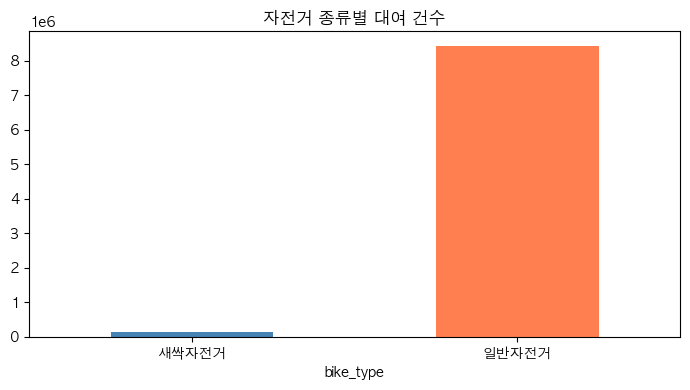

In [11]:
bike_stats = df.groupby("bike_type").agg(
    건수=("use_min", "count"),
    평균이용시간=("use_min", "mean"),
    평균이용거리=("use_m", "mean")
).round(1)
print(bike_stats)

bike_stats["건수"].plot(kind="bar", color=["steelblue", "coral", "mediumseagreen"],
                        title="자전거 종류별 대여 건수", rot=0, figsize=(7, 4))
plt.tight_layout()
plt.savefig("../reports/figures/bike_type.png", dpi=150)
plt.show()

## 7. 데이터 저장 (Processed)

In [12]:
# 정제 데이터 parquet으로 저장
save_processed(df, "rentals_clean")

# 대여소별 시간별 집계 저장
from src.data_loader import build_station_hourly
hourly = build_station_hourly(df)
save_processed(hourly, "station_hourly_demand")

print(f"\n✅ 저장 완료!")
print(f"   rentals_clean: {len(df):,}행")
print(f"   station_hourly_demand: {len(hourly):,}행")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/rentals_clean.parquet  (262.3 MB)


✅ build_station_hourly() → shape: (3835657, 5)


💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/station_hourly_demand.parquet  (13.3 MB)

✅ 저장 완료!
   rentals_clean: 8,559,939행
   station_hourly_demand: 3,835,657행


## 8. 주요 인사이트 요약

In [13]:
print("=" * 60)
print("📊 EDA 주요 인사이트")
print("=" * 60)
print(f"전체 대여 건수: {len(df):,}")
print(f"대여소 수 (대여): {df['rent_stn_id'].nunique():,}")
print(f"대여소 수 (반납): {df['rtrn_stn_id'].nunique():,}")
print(f"평균 이용시간: {df['use_min'].mean():.1f}분")
print(f"평균 이용거리: {df['use_m'].mean():.0f}m")
print(f"반납 정보 결측: {df['rtrn_stn_id'].isnull().sum():,}건 ({df['rtrn_stn_id'].isnull().mean()*100:.1f}%)")
print(f"피크 시간대: {df.groupby('hour').size().idxmax()}시")
print(f"가장 바쁜 요일: {['월','화','수','목','금','토','일'][df.groupby('dow').size().idxmax()]}요일")

📊 EDA 주요 인사이트
전체 대여 건수: 8,559,939
대여소 수 (대여): 2,782
대여소 수 (반납): 2,791
평균 이용시간: 19.9분
평균 이용거리: 2156m


반납 정보 결측: 45,962건 (0.5%)
피크 시간대: 18시
가장 바쁜 요일: 수요일
